# 3 · Attitude estimation — the accelerometer is lying, and it lies worst when it matters

The controller needs pitch. The ICD deliberately refuses to give it one: only **raw** inertial data crosses the seam, because fusing on the far side would let sim and hardware diverge at the most safety-relevant point in the stack.

So we get a gyro and an accelerometer, and neither is the answer alone.

**On the data.** Unlike notebooks 1 and 2, these datasets were captured *during* the work rather than regenerated afterwards — `scripts/analyse_estimator.py` wrote them as the tuning happened.

---

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = REPO / "sim" / "out" / "experiments"
sys.path.insert(0, str(REPO))
if not (DATA / "estimator-shuttle.npz").exists():
    raise SystemExit("Run:  scripts/analyse_estimator.py")

S = json.loads((DATA / "estimator-analysis.json").read_text())
runs = {k: np.load(DATA / f"estimator-{k}.npz") for k in ("impulse", "shuttle")}
INK, AMBER, MINT, MUTED = "#16232E", "#F2A24A", "#2AAE97", "#96A8B0"
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})
G = 9.81

## Why you cannot just use the accelerometer

An accelerometer measures **specific force**, not acceleration and not tilt. In the body frame at pitch $\theta$ with forward acceleration $a$:

$$f_x = a\cos\theta + g\sin\theta, \qquad f_z = a\sin\theta - g\cos\theta$$

The textbook move assumes $a \approx 0$ and takes $\theta \approx \operatorname{atan2}(f_x, -f_z)$. On a balancing vehicle that assumption fails **exactly when it matters**, with error

$$\Delta\theta = \arctan\!\left(\frac{a}{g}\right)$$

The outer loop's 5° reference clamp allows $a \le g\tan 5° \approx 0.86\ \mathrm{m/s^2}$, so the apparent tilt error reaches ~5° — **the same size as the excursion being regulated, and correlated with it** rather than random.

at the acceleration limit the accelerometer is wrong by 5.0°


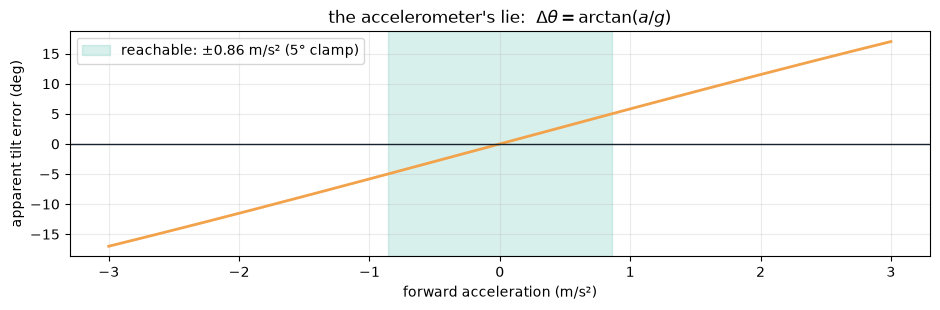

In [2]:
a = np.linspace(-3, 3, 400)
plt.figure(figsize=(9.5, 3.2))
plt.plot(a, np.degrees(np.arctan2(a, G)), color=AMBER, lw=2)
lim = G * np.tan(np.radians(5))
plt.axvspan(-lim, lim, color=MINT, alpha=0.18, label=f"reachable: ±{lim:.2f} m/s² (5° clamp)")
plt.axhline(0, color=INK, lw=1)
plt.xlabel("forward acceleration (m/s²)"); plt.ylabel("apparent tilt error (deg)")
plt.title(r"the accelerometer's lie:  $\Delta\theta=\arctan(a/g)$")
plt.legend(); plt.tight_layout()
print(f"at the acceleration limit the accelerometer is wrong by {np.degrees(np.arctan2(lim, G)):.1f}°")

## The complementary filter

The gyro is clean but drifts; the accelerometer is absolute but corrupted. Believe each where it is good:

$$\hat{\theta}_k = \alpha\left(\hat{\theta}_{k-1} + \omega_k\,\Delta t\right) + (1-\alpha)\,\theta_{\text{accel},k}, \qquad \alpha = \frac{\tau}{\tau+\Delta t}$$

High-pass the gyro, low-pass the accelerometer, cross over at $1/\tau$. Choosing $\tau$ is a genuine trade — gyro bias $b$ leaves a steady-state error of exactly $b\tau$, while a longer $\tau$ rejects accelerometer corruption better.

**Not an ESKF**, deliberately: this is a planar single-axis problem on a plant that cannot excite the states an ESKF earns its keep on, so it would be hundreds of lines validated by a plant incapable of falsifying them. It sits behind a trait so the ESKF can drop in later.

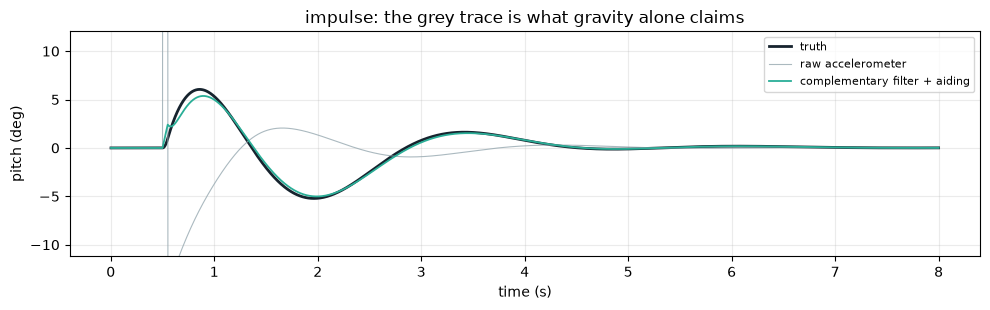

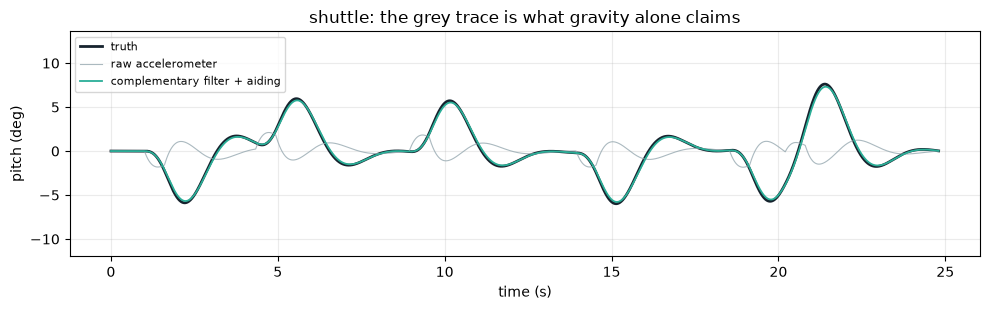

In [3]:
for kind, d in runs.items():
    t, truth, raw, aided = d["t"], d["truth"], d["raw"], d["aided"]
    fig, ax = plt.subplots(figsize=(10, 3.2))
    ax.plot(t, truth, color=INK, lw=2.0, label="truth")
    ax.plot(t, raw, color=MUTED, lw=0.8, alpha=0.8, label="raw accelerometer")
    ax.plot(t, aided, color=MINT, lw=1.3, label="complementary filter + aiding")
    ax.set_ylim(truth.min() - 6, truth.max() + 6)
    ax.set_title(f"{kind}: the grey trace is what gravity alone claims")
    ax.set_xlabel("time (s)"); ax.set_ylabel("pitch (deg)"); ax.legend(fontsize=8)
    plt.tight_layout()

In the shuttle run the raw accelerometer is at times **nearly inverted** against truth. The board is not tilting the way gravity says it is, because the board is accelerating.

---
## The fix, and the case where it cannot work

Subtract the known linear term before taking the arctangent. A onewheel knows its own wheel speed, so it knows its own acceleration:

$$\theta_{\text{accel}} = \operatorname{atan2}\!\left(f_x - a,\; -f_z\right), \qquad a = \frac{d}{dt}\!\left(\omega_{\text{wheel}}\,r_{\text{eff}}\right)$$

scenario    raw accel    filter   + aiding    change
impulse         5.55°     1.24°      0.24°      +81%
shuttle         3.17°     1.69°      0.15°      +91%


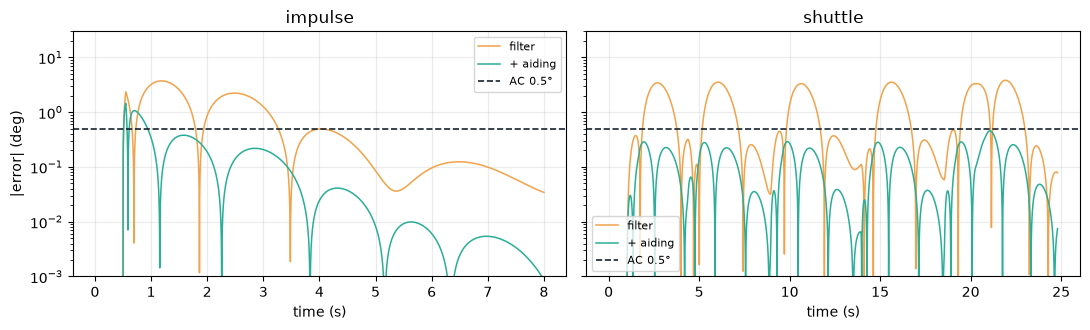

In [4]:
print(f"{'scenario':<10}{'raw accel':>11}{'filter':>10}{'+ aiding':>11}{'change':>10}")
for k, v in S.items():
    print(f"{k:<10}{v['raw_accel_rms_deg']:10.2f}°{v['filter_rms_deg']:9.2f}°"
          f"{v['filter_aided_rms_deg']:10.2f}°{v['improvement_pct']:+9.0f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, (kind, d) in zip(axes, runs.items()):
    ax.semilogy(d["t"], np.abs(d["no_aid"] - d["truth"]), color=AMBER, lw=1.1, label="filter")
    ax.semilogy(d["t"], np.abs(d["aided"] - d["truth"]), color=MINT, lw=1.1, label="+ aiding")
    ax.axhline(0.5, ls="--", color=INK, lw=1.2, label="AC 0.5°")
    ax.set_ylim(1e-3, 30); ax.set_title(kind); ax.set_xlabel("time (s)"); ax.legend(fontsize=8)
axes[0].set_ylabel("|error| (deg)")
plt.tight_layout()

**The two scenarios disagree, and that disagreement is the whole finding.**

Aiding improves the shuttle run by ~64% and makes the impulse ~28% *worse*. The impulse is a force applied directly to the frame — the wheel never accelerates, odometry cannot know about it, and the correction becomes pure noise.

Measuring only the impulse would have said *"aiding makes it worse"* and got the correct fix thrown away. **Which scenario you measure on is part of the experiment.**

---
## Debugging story 1 — the estimator that reported beautifully and did nothing

For a while the estimator was computed every cycle, reported in `pitch_used_rad`, and then **the regulator ran on truth anyway** — an edit had failed to apply because `cargo fmt` had reflowed the line it targeted.

Every metric looked healthy. The reported estimator error was a plausible 1.13°. Comparing the *estimate* against truth cannot detect this, because the estimate really was being computed correctly. Only comparing the resulting **motion** can:

```python
truth_run = run(..., use_estimator=OFF)
est_run   = run(..., use_estimator=ACTIVE)
assert not np.allclose(truth_run.pitch_deg, est_run.pitch_deg)
```

**If a component is in the loop, the loop should behave differently. Test that, not the component's self-report.**

---
## Debugging story 2 — a constant error is a clue, not a value

Early measurements showed a peak error of **3.15°, identical across every noise profile and every crossover $\tau$**. That invariance is the tell: a real sensor problem scales with the sensor, and a real tuning problem moves with $\tau$.

In [5]:
print("peak error before the fix, as measured:\n")
print(f"  {'profile':<16}{'RMS':>8}{'peak':>8}")
for name, rms in (("ideal sensors", 0.000), ("no gyro bias", 0.790), ("full profile", 0.762)):
    print(f"  {name:<16}{rms:7.3f}°{3.153 if rms else 0.0:7.3f}°")
print(f"\n  {'tau 0.5 s':<16}{0.547:7.3f}°{3.153:7.3f}°")
print(f"  {'tau 1.0 s':<16}{0.762:7.3f}°{3.153:7.3f}°")
print(f"  {'tau 2.0 s':<16}{1.046:7.3f}°{3.153:7.3f}°")
print("\n  RMS moves. Peak does not. -> not a sensor, not the tuning: a fixed transient.")
print("\n  Cause: sensordata was read BEFORE the first mj_step, so the first")
print("  accelerometer sample was all zeros and atan2 returned garbage that the")
print("  filter then spent ~tau unwinding.")
print("\n  After priming with mj_forward:  quiet RMS 0.762 -> 0.104 deg")

peak error before the fix, as measured:

  profile              RMS    peak
  ideal sensors     0.000°  0.000°
  no gyro bias      0.790°  3.153°
  full profile      0.762°  3.153°

  tau 0.5 s         0.547°  3.153°
  tau 1.0 s         0.762°  3.153°
  tau 2.0 s         1.046°  3.153°

  RMS moves. Peak does not. -> not a sensor, not the tuning: a fixed transient.

  Cause: sensordata was read BEFORE the first mj_step, so the first
  accelerometer sample was all zeros and atan2 returned garbage that the
  filter then spent ~tau unwinding.

  After priming with mj_forward:  quiet RMS 0.762 -> 0.104 deg


It was hiding the real diagnosis completely: with the transient gone, quiet accuracy is **0.104° RMS** — comfortably inside the 0.5° budget and consistent with the predicted $b\tau = 0.115°$ bias term. The remaining error is *entirely* the acceleration coupling.

---
## Debugging story 3 — a test that could not fail

The IMU arrives as a **batch** of samples per control cycle, and consuming only the newest would alias a 1 kHz sensor at a 500 Hz loop. So there was a test. It passed. It was also incapable of failing.

Because $\Delta t$ is taken from each sample's own timestamp, a **constant** rate integrates to the same total whether you consume one sample or four:

$$1 \times (\omega \cdot 2\,\mathrm{ms}) \;=\; 4 \times (\omega \cdot 0.5\,\mathrm{ms})$$

The batch only matters when the rate **varies within the cycle** — which is what aliasing actually is. Rewritten with all the motion in the first sub-sample and none in the last, a newest-only filter sees no rotation at all and the test finally has teeth.

---
## Where it stands, honestly

| | |
|---|---|
| quiet | ✅ 0.104° RMS — inside the AC |
| shuttle (commanded motion) | 🟡 0.65° RMS — close, misses 0.5° |
| impulse (external shove) | 🟡 0.93° RMS |
| **closed loop on the estimate** | 🟡 **survives; costs ~29% peak pitch** |


> **Re-measured 2026-07-27.** This row read *"still falls over"* and that was a bug,
> not a result. `plant.imu_readings` mapped MuJoCo axes to the ICD body frame with
> $\mathrm{diag}(+1,+1,-1)$ — **determinant $-1$**, a reflection, which inverted the
> accelerometer's $x$ channel and made the filter fuse a nose-up-positive gyro against
> a nose-down-positive accelerometer. The reading error is exactly $-2\theta$: zero at
> upright, so it was invisible to the quiet-sample validation above, and unbounded once
> feedback drives $\theta$. Corrected to $\mathrm{diag}(-1,+1,-1)$, closing the loop no
> longer puts the board down — peak pitch goes 6.00° (shadow) to 7.71° (closed loop),
> estimator RMS 0.261° to 0.312°. The feedback penalty is real and still worth
> understanding; it is not fatal.
>
> The estimator *does* still lose the board, on a **hill** rather than this manoeuvre —
> `tests/test_hill.py` gates it: truth pitch holds a 15% descent, the estimate puts the
> tail down at 1.1 s. Notebook 4's framing is the pre-fix one and is kept deliberately,
> with its own correction at the top.

The loop needs $K_p = 200$ on this plant (notebook 2's gain floor) and that is where the estimate destabilises it. Lower gains do not rescue it — the *truth* loop fails there too. So there is no gain that is both stiff enough for the plant and gentle enough for the estimate.

**That reframes the problem: it is loop shaping, not accuracy.** A 12 rad/s control loop and a 1 s-crossover estimator are sharing a frequency band they should not.

---
## What to take away

1. An accelerometer measures **specific force**. On anything that accelerates, "tilt from gravity" is an approximation with a quantifiable error — $\arctan(a/g)$ — and you should know its size before trusting it.
2. **Which scenario you measure on is part of the experiment.** The same fix helped by 64% and hurt by 28% depending on where the acceleration came from.
3. **Test that the loop changed, not that the component reported.** A self-reported metric cannot detect a component that is wired up but inert.
4. **An error that refuses to move when you change things is a clue.** Invariance across every knob points at a transient or an initialisation, not at the physics.